In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Unemployment in India.csv')

# Clean column names by stripping trailing/leading whitespaces
df.columns = df.columns.str.strip()

# Inspect shape and basic info
print("Dataset Shape:", df.shape)
print("\nNull Value Check:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# Data Type Conversion
df['Date'] = pd.to_datetime(df['Date'].str.strip(), errors='coerce')
df['Frequency'] = df['Frequency'].astype('category')
df['Area'] = df['Area'].astype('category')

# Drop rows with missing dates or values if any
df = df.dropna(subset=['Date', 'Estimated Unemployment Rate (%)'])

Dataset Shape: (768, 7)

Null Value Check:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Data Types:
 Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object


/tmp/ipykernel_646/2377370261.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'].str.strip(), errors='coerce')


In [ ]:
# Region-wise average unemployment rates
region_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
region_stats = region_stats.sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
print("Top 5 States by Mean Unemployment Rate:\n", region_stats.head())

# Month-wise trend extraction
df['Month_Year'] = df['Date'].dt.to_period('M')
monthly_trend = df.groupby('Month_Year')['Estimated Unemployment Rate (%)'].mean()

Top 5 States by Mean Unemployment Rate:
               Region  Estimated Unemployment Rate (%)
24           Tripura                        28.350357
8            Haryana                        26.283214
11         Jharkhand                        20.585000
2              Bihar                        18.918214
9   Himachal Pradesh                        18.540357


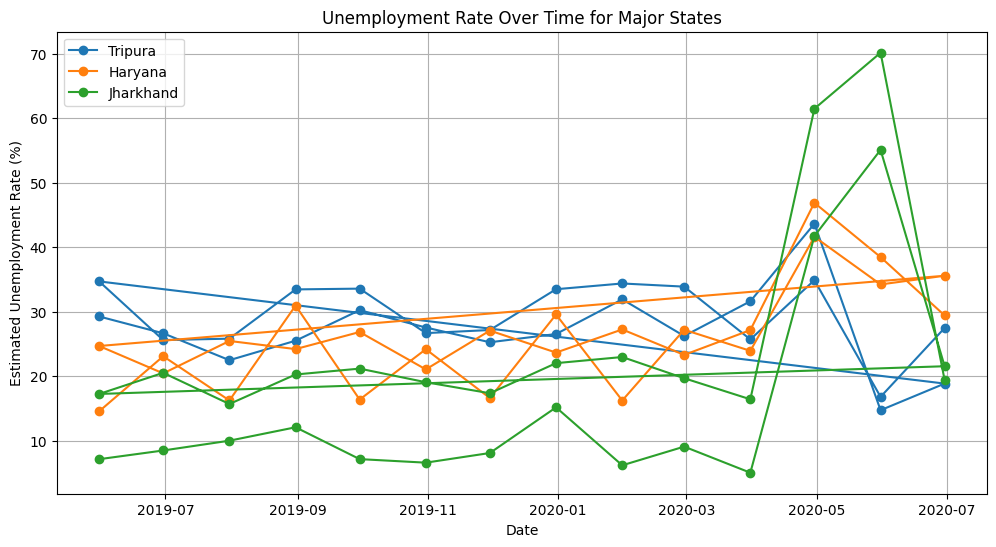

In [ ]:
plt.figure(figsize=(12, 6))
major_states = ['Tripura', 'Haryana', 'Jharkhand']
for state in major_states:
    state_data = df[df['Region'] == state]
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], marker='o', label=state)

plt.title('Unemployment Rate Over Time for Major States')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_646/3755555459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=top_10_states, palette='viridis')


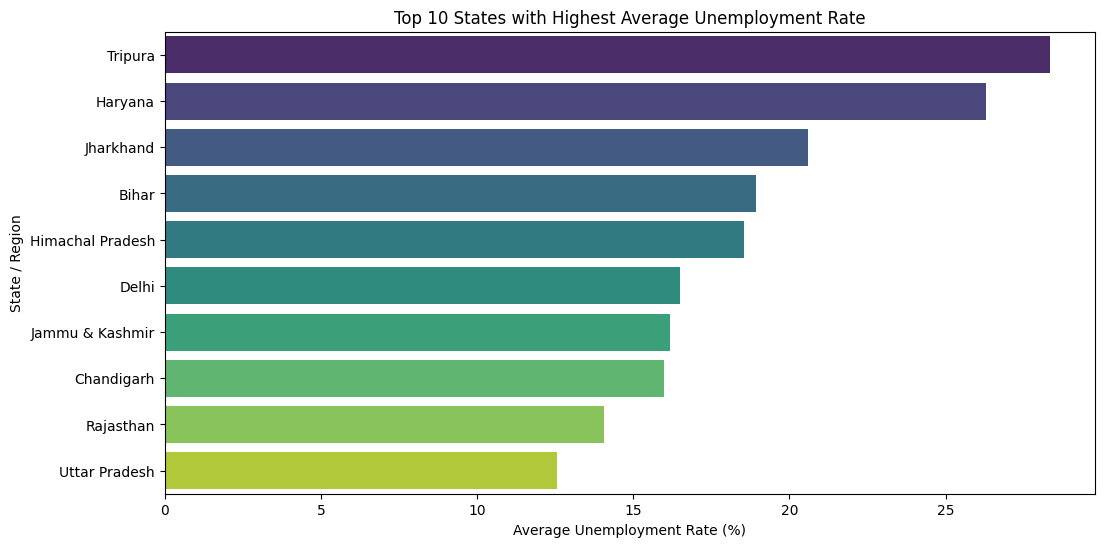

In [ ]:
top_10_states = region_stats.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=top_10_states, palette='viridis')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.show()

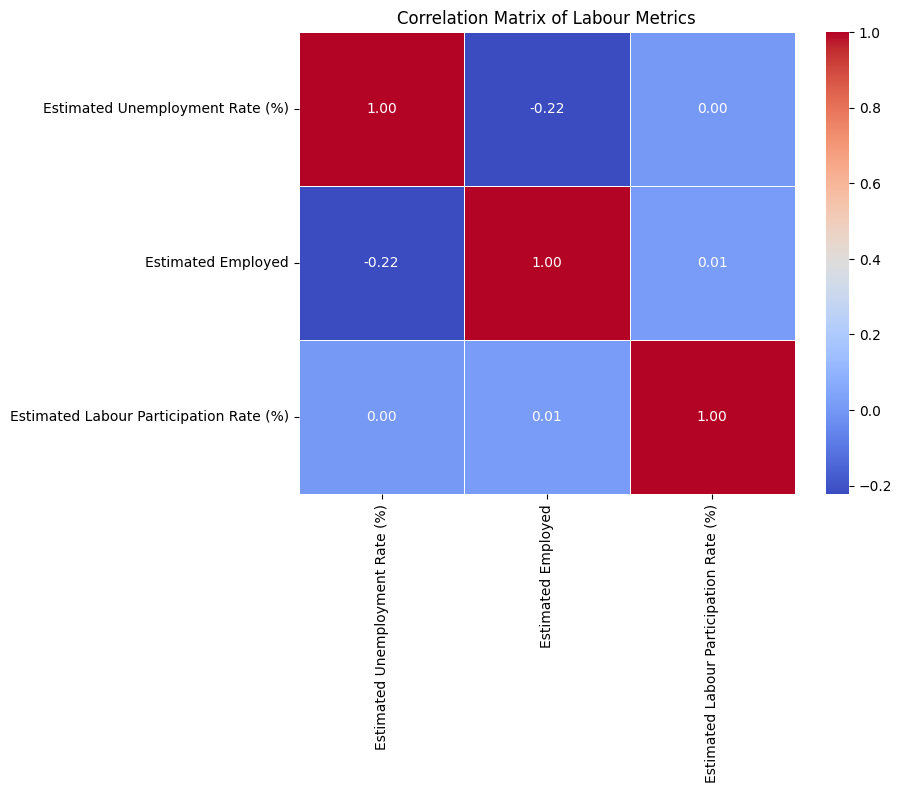

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Labour Metrics')
plt.show()

Pre-COVID Average Unemployment Rate: 9.51%
Post-COVID Average Unemployment Rate: 17.77%


/tmp/ipykernel_646/2526073299.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Mean Unemployment Rate (%)', data=comparison_df, palette='Set2')


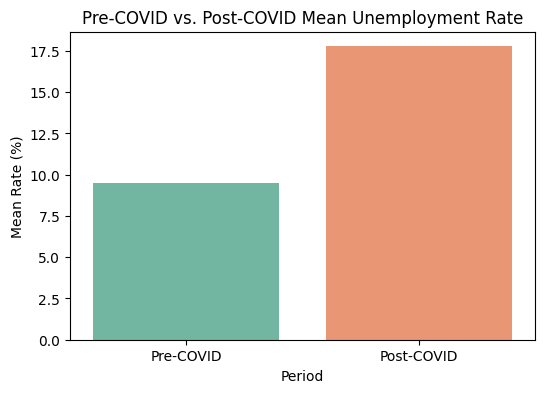

In [ ]:
# Split data based on COVID-19 lockdown milestone (March 2020)
lockdown_date = pd.to_datetime('2020-03-01')

pre_covid = df[df['Date'] < lockdown_date]
post_covid = df[df['Date'] >= lockdown_date]

pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID Average Unemployment Rate: {pre_mean:.2f}%")
print(f"Post-COVID Average Unemployment Rate: {post_mean:.2f}%")

comparison_df = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Mean Unemployment Rate (%)': [pre_mean, post_mean]
})

plt.figure(figsize=(6, 4))
sns.barplot(x='Period', y='Mean Unemployment Rate (%)', data=comparison_df, palette='Set2')
plt.title('Pre-COVID vs. Post-COVID Mean Unemployment Rate')
plt.ylabel('Mean Rate (%)')
plt.show()